# K-Means Clustering 

by

# CodeTech Mudassar

In [5]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [8]:
# Load the dataset
df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


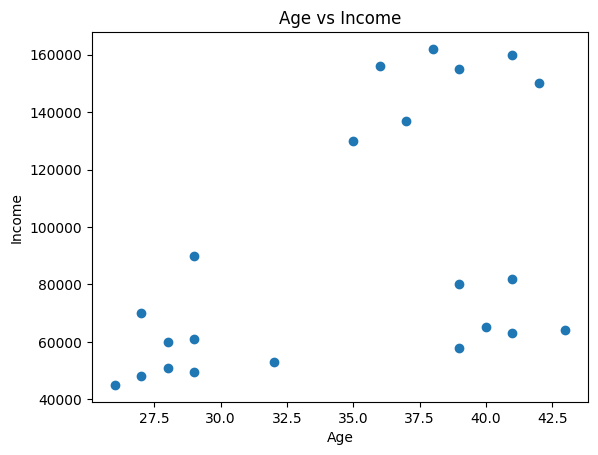

In [10]:
# scatter plot 
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

In [11]:
# now model training
X = df[['Age', 'Income($)']].values
# KMeans clustering
km = KMeans(n_clusters=3)
km.fit(X)

KMeans(n_clusters=3)

In [12]:
# prediction 
y_km = km.predict(X)
y_km

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [13]:
# now lets visualize the clusters in table 
df['Cluster'] = y_km
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,2


In [14]:
# now checking the centroids
centroids = km.cluster_centers_
centroids

array([[3.60000000e+01, 1.33500000e+05],
       [3.32000000e+01, 6.26333333e+04],
       [3.92000000e+01, 1.56600000e+05]])

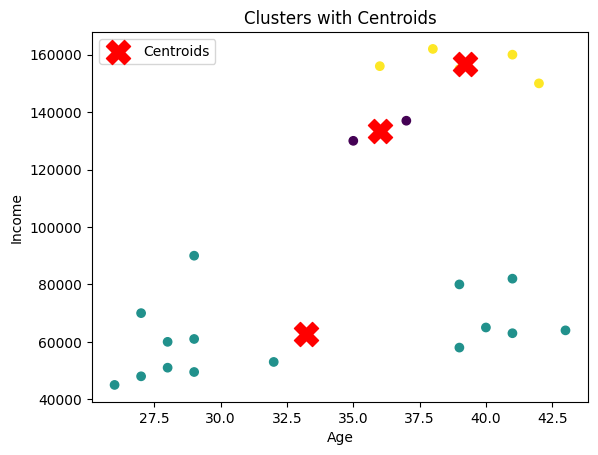

In [15]:
# now visualizing the centeroids
plt.scatter(df['Age'], df['Income($)'], c=df['Cluster'], cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Clusters with Centroids')
plt.legend()
plt.show()

**preprocessing using min max method**

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,2


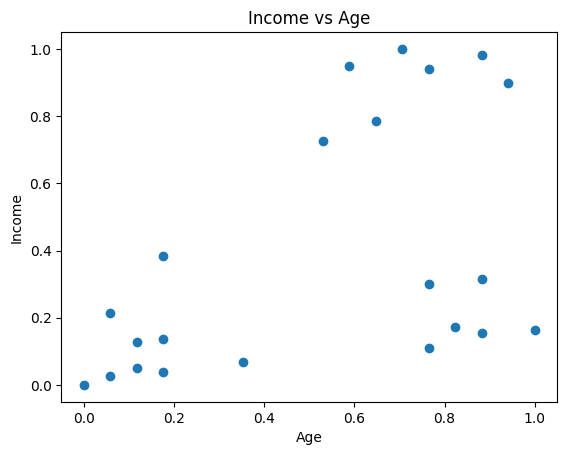

In [17]:
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')
plt.show()

In [18]:
# now model trainign
X = df[['Age', 'Income($)']]
# KMeans
km = KMeans(n_clusters=3)
# fit the model
km.fit(X)
# predict the clusters
y_km = km.predict(X)
y_km

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [19]:
# now let's visualize the clusters in table
df['Cluster'] = y_km
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [20]:
# now km centers
centers = km.cluster_centers_
centers

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

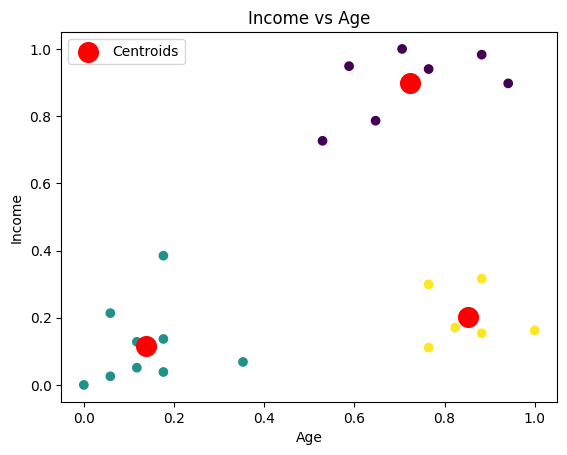

In [21]:
# now visualize the clusters also the incomes
plt.scatter(df['Age'], df['Income($)'], c=df['Cluster'])
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', label='Centroids')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')
plt.legend()
plt.show()

**Elbow plot**

In [22]:
# now let's plot the elbow 
w = []
for i in range(1, 10):
    km = KMeans(n_clusters=i)
    km.fit(X)
    w.append(km.inertia_)

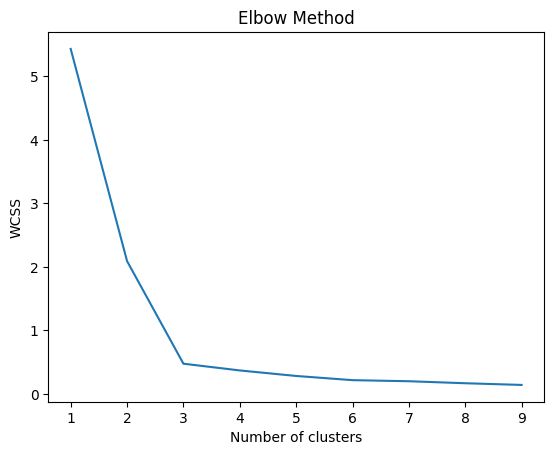

In [23]:
# elbow plot
plt.plot(range(1, 10), w)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()